### Projet 5A : Modélisation Avancée (Random Forest & SHAP)

**Objectif :** Dépasser les limites de la régression logistique en utilisant un modèle non-linéaire (Random Forest) capable de capturer des interactions complexes entre les variables.

**Pourquoi Random Forest ?**
* Gère naturellement les relations non-linéaires (ex: effet de seuil sur les cotes).
* Robuste aux outliers et au bruit.
* Moins sensible à la multicollinéarité que la régression logistique.

**Pourquoi SHAP ?**
* Pour expliquer les prédictions : Quelles variables pèsent le plus ?
* Pour comprendre le sens : Est-ce qu'une différence de forme positive favorise toujours la victoire ?

### Imports et Configuration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
from sklearn.model_selection import TimeSeriesSplit

# Configuration
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
shap.initjs() # Nécessaire pour les graphiques SHAP interactifs

# Constantes
TARGET_COL = "FTResult"
TARGET_MAPPER = {'H': 0, 'D': 1, 'A': 2}
CLASS_LABELS = ["Home", "Draw", "Away"]

### Préparation des Données
Contrairement à la régression logistique :
1.  **Pas besoin de standardiser** (StandardScaler) : Les arbres sont insensibles à l'échelle.
2.  **Moins de contraintes de collinéarité :** On peut garder les cotes brutes ET les probabilités si on veut, le modèle choisira la meilleure coupure.

In [6]:
PATH_DATA = "C:/Users/Alban/Documents/IMDS/Projet_5A/Donnees/matches_select_championnats.csv"

def load_data_for_trees(path):
    try:
        df = pd.read_csv(path, sep=";", parse_dates=["MatchDate"], dayfirst=True)
    except:
        df = pd.read_csv(path, sep=",", parse_dates=["MatchDate"], dayfirst=True)
    
    # 1. Encodage Cible
    if TARGET_COL in df.columns:
        df = df[df[TARGET_COL].isin(["H", "D", "A"])]
        df["target"] = df[TARGET_COL].map(TARGET_MAPPER)
    
    # 2. Feature Engineering "Métier"
    # On crée les variables les plus porteuses de sens
    if "OddHome" in df.columns:
        # Probabilités implicites (souvent plus informatives que la cote brute)
        df["ImpProb_Home"] = 1 / df["OddHome"]
        df["ImpProb_Draw"] = 1 / df["OddDraw"]
        df["ImpProb_Away"] = 1 / df["OddAway"]
    
    # 3. Sélection des Features
    # Pour un Random Forest, on peut donner plus de contexte
    features = [
        "EloDiff",          # Force relative
        "Form5Diff",        # Dynamique récente
        "ImpProb_Home", "ImpProb_Draw", "ImpProb_Away", # Le marché
        "HandiSize",        # Si disponible : info précieuse sur l'écart attendu
        "Season"            # Contexte temporel
    ]
    
    # Filtrage des colonnes existantes
    features = [c for c in features if c in df.columns]
    
    # 4. Nettoyage NaN/Inf
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=features + ["target"]).reset_index(drop=True)
    
    # Tri temporel (Crucial pour le split)
    df = df.sort_values("MatchDate").reset_index(drop=True)
    
    return df, features

df_tree, tree_features = load_data_for_trees(PATH_DATA)
print(f"Données prêtes : {df_tree.shape}")
print(f"Features : {tree_features}")

Données prêtes : (47352, 52)
Features : ['EloDiff', 'Form5Diff', 'ImpProb_Home', 'ImpProb_Draw', 'ImpProb_Away', 'HandiSize', 'Season']


### Entraînement du Random Forest
On utilise toujours une validation temporelle (`TimeSeriesSplit`) pour ne pas tricher avec le futur.
Nous limitons la profondeur des arbres (`max_depth`) pour éviter le sur-apprentissage (overfitting), très courant sur les données sportives bruitées.

In [7]:
def run_random_forest(df, features, n_splits=3):
    
    # TimeSeriesSplit de sklearn est très pratique ici
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Stockage pour le dernier modèle (pour SHAP)
    last_model = None
    last_X_val = None
    last_y_val = None
    
    X = df[features]
    y = df["target"]
    
    print(f"--- DÉBUT DE LA VALIDATION CROISÉE ({n_splits} splits) ---")
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # Configuration du RF (Hyperparamètres conservateurs pour éviter l'overfitting)
        clf = RandomForestClassifier(
            n_estimators=200,     # Nombre d'arbres
            max_depth=7,          # Profondeur max (Essentiel pour ne pas overfit)
            min_samples_leaf=50,  # Nombre min d'exemples par feuille (Lissage)
            random_state=42,
            n_jobs=-1             # Parallélisation
        )
        
        clf.fit(X_train, y_train)
        
        # Prédictions
        y_pred = clf.predict(X_val)
        y_prob = clf.predict_proba(X_val)
        
        # Métriques
        acc = accuracy_score(y_val, y_pred)
        ll = log_loss(y_val, y_prob)
        
        # Baseline Marché (pour comparer)
        market_pred = X_val[["ImpProb_Home", "ImpProb_Draw", "ImpProb_Away"]].idxmax(axis=1).map({
            "ImpProb_Home":0, "ImpProb_Draw":1, "ImpProb_Away":2
        })
        market_acc = accuracy_score(y_val, market_pred)
        
        print(f"Fold {fold+1} | Acc: {acc:.4f} (Marché: {market_acc:.4f}) | LogLoss: {ll:.4f}")
        
        # On garde le dernier fold pour l'analyse SHAP
        if fold == n_splits - 1:
            last_model = clf
            last_X_val = X_val
            last_y_val = y_val
            
    return last_model, last_X_val, last_y_val

# Exécution
rf_model, X_val_shap, y_val_shap = run_random_forest(df_tree, tree_features)

--- DÉBUT DE LA VALIDATION CROISÉE (3 splits) ---
Fold 1 | Acc: 0.5199 (Marché: 0.5228) | LogLoss: 0.9863
Fold 2 | Acc: 0.5115 (Marché: 0.5124) | LogLoss: 0.9943
Fold 3 | Acc: 0.5262 (Marché: 0.5257) | LogLoss: 0.9806


### Analyse SHAP (SHapley Additive exPlanations)
SHAP permet de comprendre comment chaque feature a poussé la prédiction vers une équipe ou une autre.
* **Global Feature Importance :** Quelles variables comptent le plus ?
* **Beeswarm Plot :** Comment la valeur d'une variable influence le résultat (ex: EloDiff élevé => Victoire Home ?).

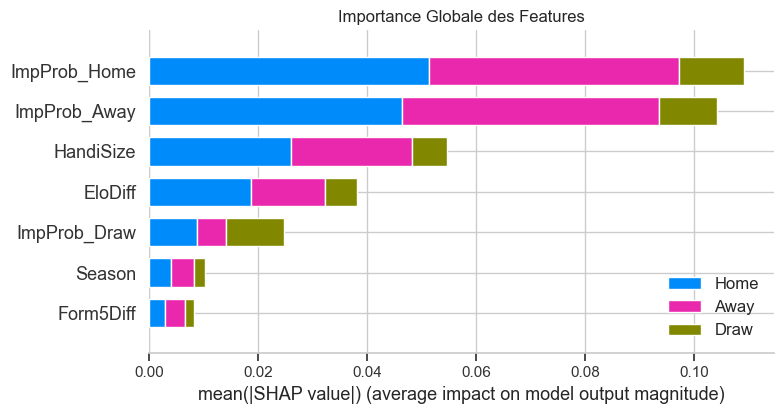


--- Analyse détaillée pour 'Victoire Domicile' ---
Rouge = Valeur élevée de la variable (ex: EloDiff positif)
Bleu  = Valeur faible de la variable (ex: EloDiff négatif)
À droite de l'axe 0 = Augmente la probabilité de victoire à domicile
À gauche de l'axe 0 = Diminue la probabilité


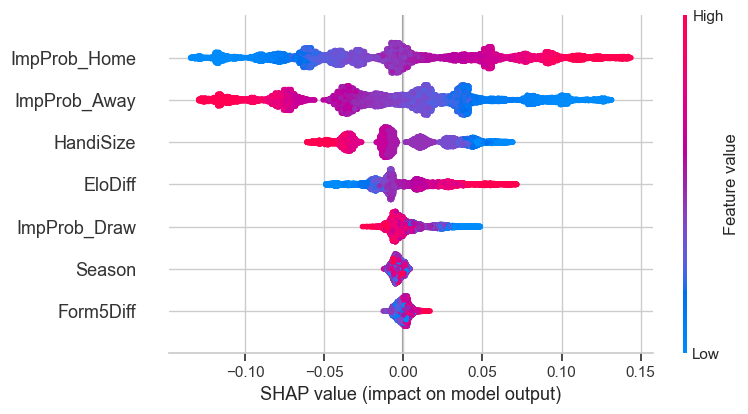

In [8]:
# Création de l'explainer (Spécifique pour les arbres)
# Attention : Sur de gros datasets, on peut prendre un échantillon pour accélérer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_val_shap, check_additivity=False)

# --- CORRECTION DE LA SÉLECTION DES CLASSES ---

# SHAP peut renvoyer soit une liste, soit un array numpy. On gère les deux cas.
if isinstance(shap_values, list):
    # Cas 1 : Liste de matrices [Classe0, Classe1, Classe2]
    shap_val_home = shap_values[0] 
    shap_val_draw = shap_values[1]
    shap_val_away = shap_values[2]
else:
    # Cas 2 : Array 3D (Samples, Features, Classes) -> C'est probablement votre cas
    # On slice pour récupérer : [Toutes les lignes, Toutes les colonnes, Classe X]
    shap_val_home = shap_values[:, :, 0]
    shap_val_draw = shap_values[:, :, 1]
    shap_val_away = shap_values[:, :, 2]

# --- AFFICHAGE ---

# 1. Importance Globale des Features (Bar plot)
# Note : Pour le summary_plot "bar", on peut passer la structure complète
plt.figure()
plt.title("Importance Globale des Features")
shap.summary_plot(shap_values, X_val_shap, plot_type="bar", class_names=CLASS_LABELS)

# 2. Analyse Détaillée pour la classe "Home Win" (0)
print("\n--- Analyse détaillée pour 'Victoire Domicile' ---")
print("Rouge = Valeur élevée de la variable (ex: EloDiff positif)")
print("Bleu  = Valeur faible de la variable (ex: EloDiff négatif)")
print("À droite de l'axe 0 = Augmente la probabilité de victoire à domicile")
print("À gauche de l'axe 0 = Diminue la probabilité")

plt.figure()
# On utilise ici la matrice spécifique à la classe "Home" qu'on a extraite
shap.summary_plot(shap_val_home, X_val_shap)

### Matrice de Confusion
Vérifions si le Random Forest arrive mieux à prédire les matchs nuls que la Régression Logistique.

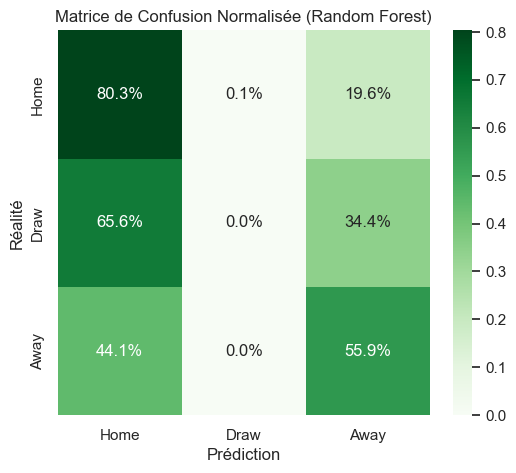

In [9]:
y_pred_final = rf_model.predict(X_val_shap)
cm = confusion_matrix(y_val_shap, y_pred_final, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Greens', 
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title("Matrice de Confusion Normalisée (Random Forest)")
plt.ylabel("Réalité")
plt.xlabel("Prédiction")
plt.show()


========== DÉBUT DE L'ANALYSE XGBOOST ==========
Fold 1 | Acc: 0.5211 (Marché: 0.5229 | Diff: -0.0018) | LogLoss: 0.9890
Fold 2 | Acc: 0.5114 (Marché: 0.5124 | Diff: -0.0010) | LogLoss: 0.9950
Fold 3 | Acc: 0.5220 (Marché: 0.5256 | Diff: -0.0036) | LogLoss: 0.9844

--- Analyse SHAP (XGBoost) ---


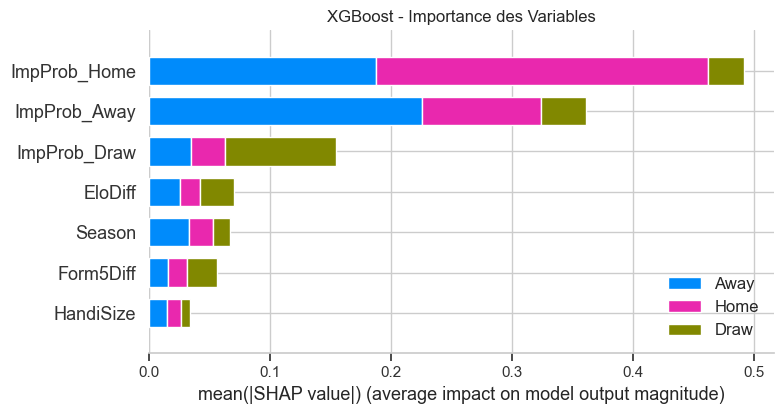

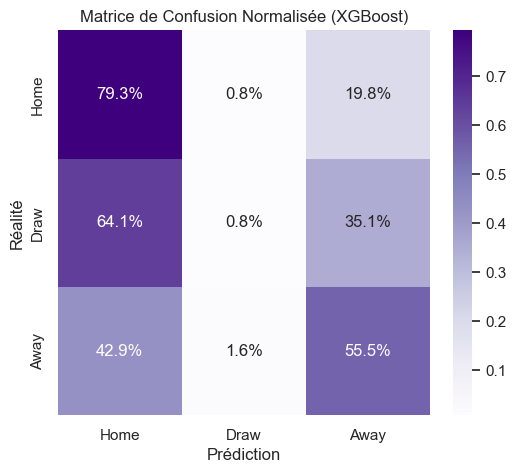